In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 4
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 


    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  ,

    feature_popdens     = True,
    feature_gisd        = True,
    feature_popage      = True,
    )    


epidata_orchestrator  = (EpiDataOrchestrator(config)
                      .load_raw()
                      .harmonize_raw()
                      .process_data()
                      .build_features()
                      .normalize()
                      .finalize()
                      )

In [2]:
from src.dataloading import BaseLineDataLoaderManager, GraphDataLoaderManager
baselinedata             = BaseLineDataLoaderManager(epidata_orchestrator)

n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

graphdataloader_ig       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('identity_graph').build()
graphdataloader_gn       = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('geographical_neighbors1').build()
graphdataloader_cm21     = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_1').build()


In [3]:
from src.models import SimpleGCNModel, GATv2LSTMModel, LSTMModel, GCNLSTMModel

In [4]:
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel 
from src.evaluation import Evaluator

persistence = PersistenceModel(baselinedata)
persistence.forecast()

climateology = ClimateologyModel(baselinedata)
climateology.forecast()

climascale = ClimaScaleModel(baselinedata)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]

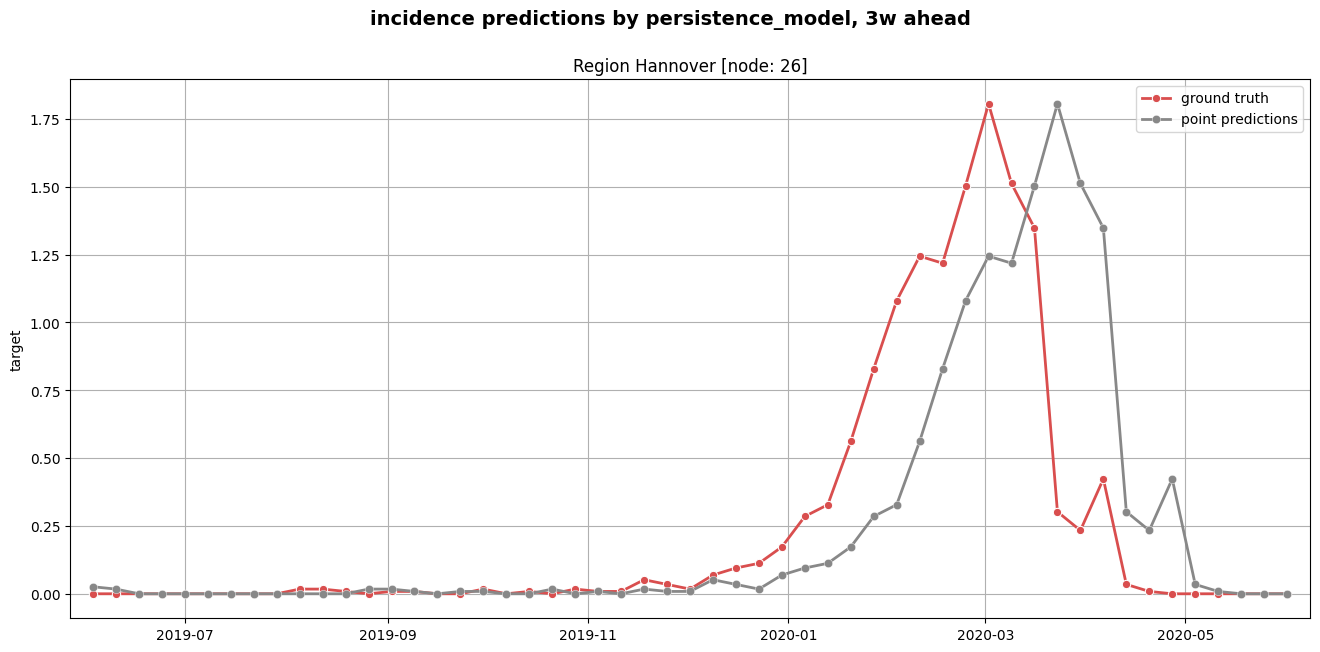

In [6]:
persistence.show_forecasts(26).show()


==                    model1                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 22, 4), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8601   |   1.0031   |    ✓     |           |
|  002  |   0.6643   |   0.8823   |    ✓     |           |
|  003  |   0.5978   |   0.8002   |    ✓     |           |
|  004  |   0.5606   |   0.7335   |    ✓     |           |
|  005  |   0.5330   |   0.6785   |    ✓     |           |
|  006  |   0.5135   |   0.6353   |    ✓     |           |
|  007  |   0.4959   |   0.6022   |    ✓     |           |
|  008  |   0.4844   |   0.5729   |    ✓     |           |
|  009  |   0.4741   |   0.5456   |    ✓     |           |
|  010  |   0.4634   |   0.5247   |    ✓     |           |
|  011  |   0.4510   |   0.5067   |    ✓     |           |
|  012  |   0.4443   |   0.4881   |    ✓

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:332: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.3598
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 305.22it/s]


Test loss: 0.5138
forecasted ✓


GCNLSTMModel(name='model1')

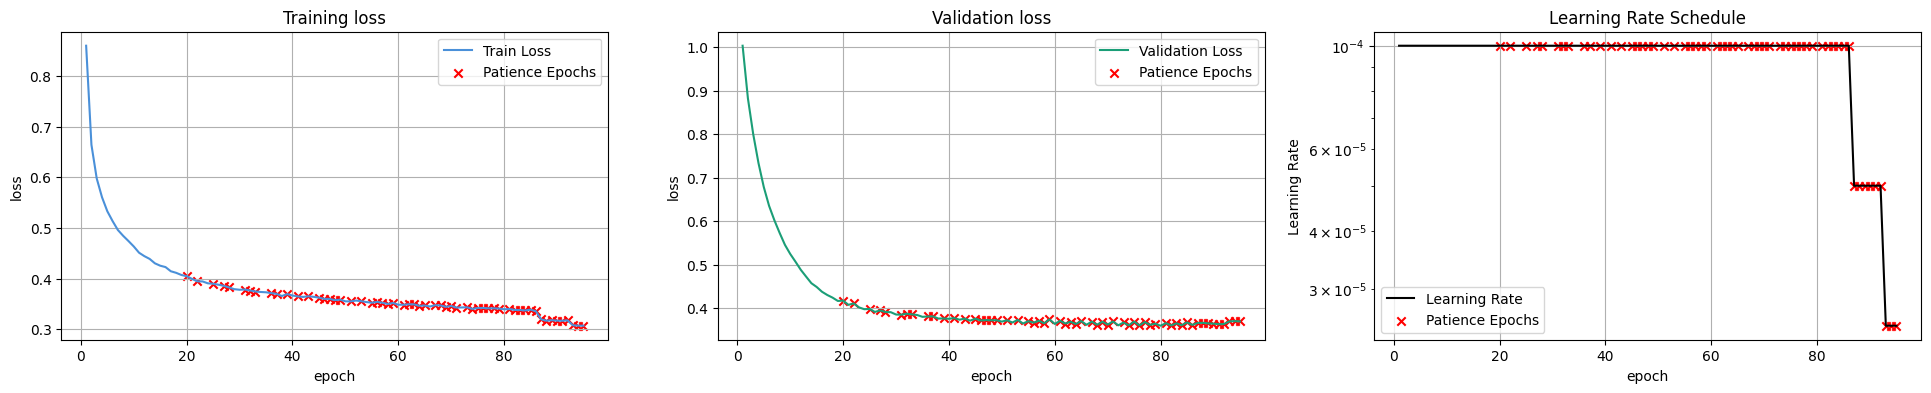

In [11]:
global_hparams = {
    'lr'    :   1e-4,
    'min_delta' : 0.0005,
    'n_epochs': 250,
    'patience':15,
    'scheduler':'plateau',
    'scheduler_kwargs': {'mode': 'min', 'factor': 0.5, 'patience': 5},
    }

ml1 = GCNLSTMModel(graphdataloader_ig, name = 'model1',verbose = 2)
ml1.set_model_hparams()
ml1.set_global_hparams(**global_hparams)
ml1.train()
ml1.forecast()

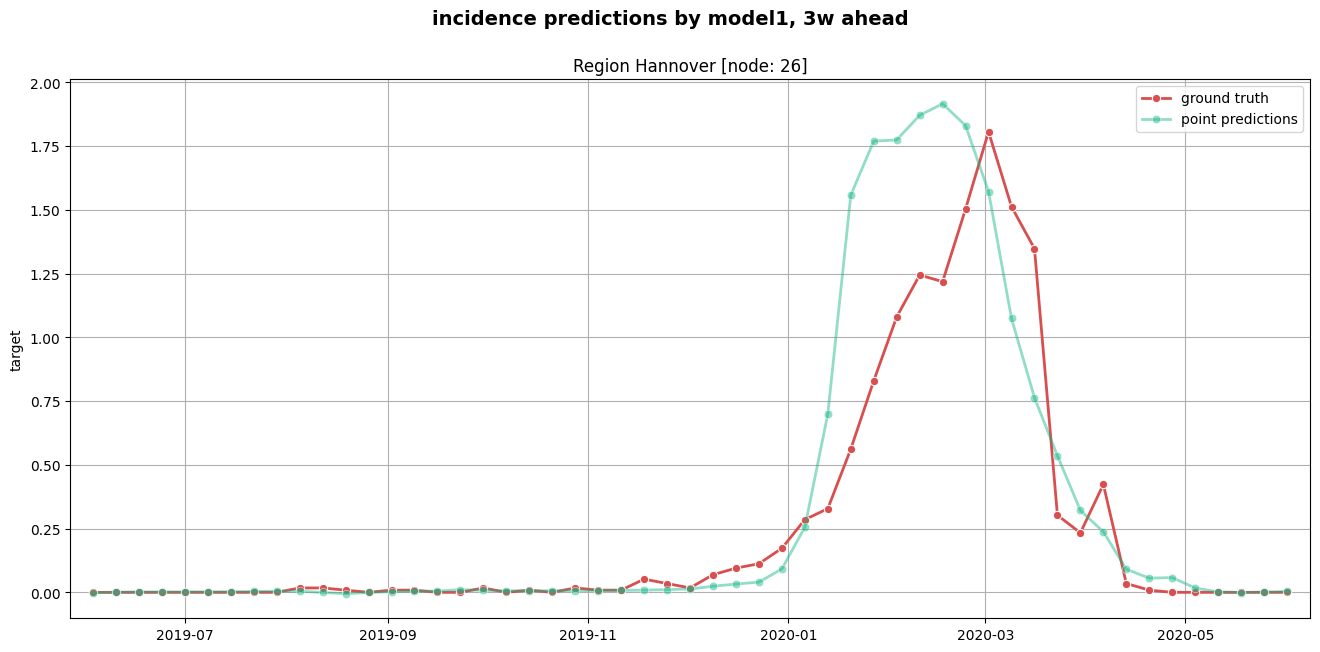

In [11]:
ml1.show_forecasts(26).show()


==                    model1                    ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 22, 4), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.7937   |   0.9231   |    ✓     |           |
|  002  |   0.6492   |   0.7840   |    ✓     |           |
|  003  |   0.5924   |   0.6973   |    ✓     |           |
|  004  |   0.5590   |   0.6374   |    ✓     |           |
|  005  |   0.5404   |   0.5988   |    ✓     |           |
|  006  |   0.5198   |   0.5717   |    ✓     |           |
|  007  |   0.5107   |   0.5454   |    ✓     |           |
|  008  |   0.4972   |   0.5317   |    ✓     |           |
|  009  |   0.4847   |   0.5147   |    ✓     |           |
|  010  |   0.4801   |   0.5053   |    ✓     |           |
|  011  |   0.4690   |   0.4908   |    ✓     |           |
|  012  |   0.4627   |   0.4839   |   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:332: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.3706
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 132.13it/s]


Test loss: 0.5032
forecasted ✓


GCNLSTMModel(name='model1')

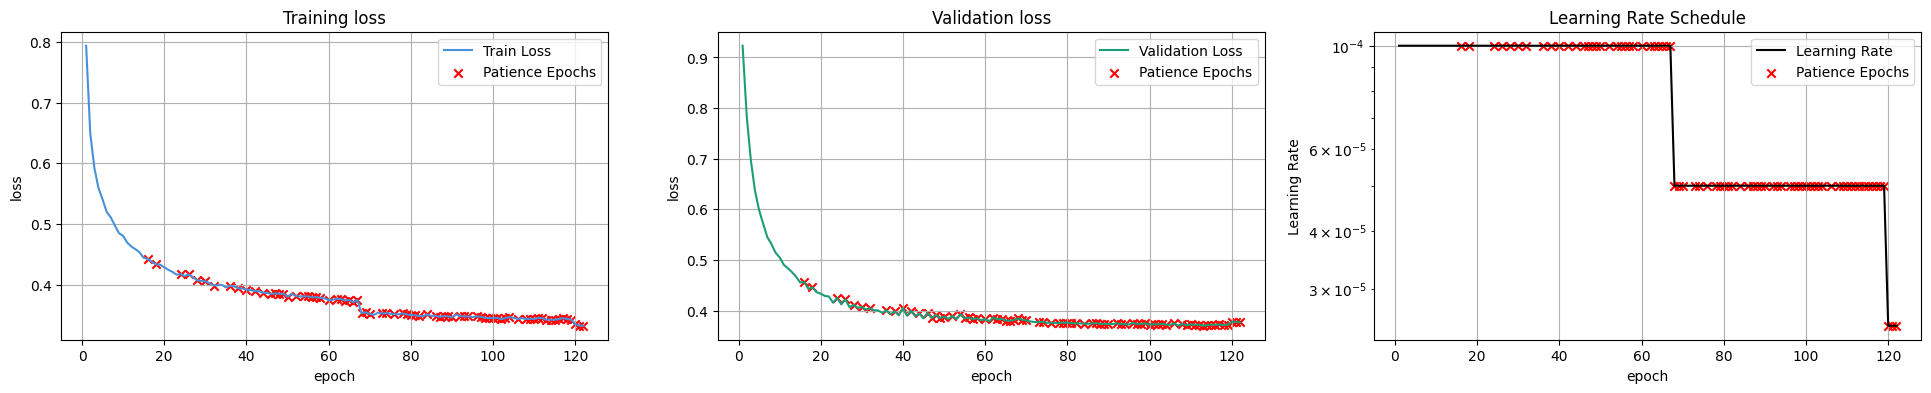

In [12]:
ml1 = GCNLSTMModel(graphdataloader_gn, name = 'model1',verbose = 2)
ml1.set_model_hparams()
ml1.set_global_hparams(**global_hparams)
ml1.train()
ml1.forecast()

computing metrics:   0%|                                                                                                                                                                | 0/9 [00:00<?, ?it/s]

computing metrics:  89%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                 | 8/9 [00:08<00:01,  1.03s/it]/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: invalid value encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/metrics.py:58: RuntimeWarning: invalid value encountered in scalar divide
  r2=  float(1 - ss_res/ ss_tot)
computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:09<00:00,  1.04s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/

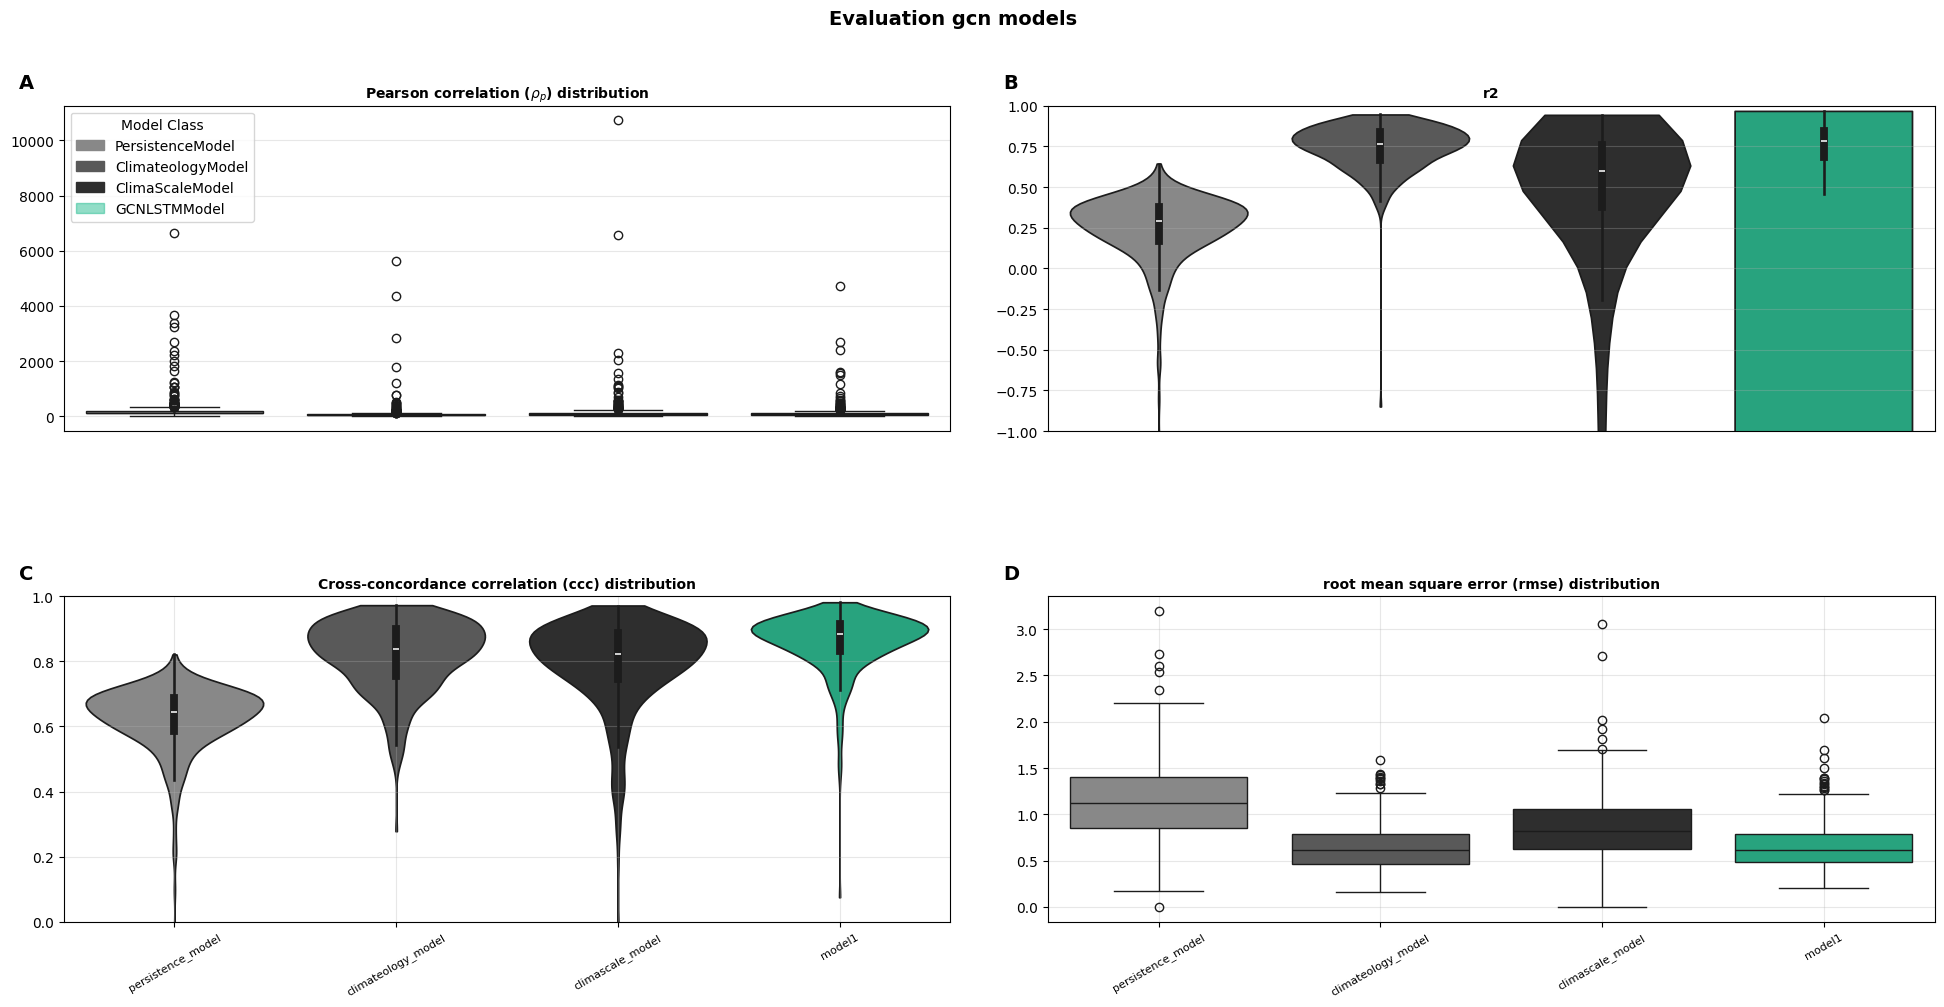

In [13]:
evaluation_experiment_sgnn = Evaluator(baseline_models + [ml1]).add_evaluation()
f_merged_raw    = evaluation_experiment_sgnn.plotter.plot_metric_compilation(metrics = ['mape','r2','ccc','rmse'], subfig_size = (8,4), plot_types = ['box','violin','violin','box']);

f_merged = (f_merged_raw
    .labels.change_suptitle(suptitle='Evaluation gcn models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 0)
    .labels.change_title('r2',  fontweight = 'bold',     ax = 1)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 2)    
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)   
    # .layout.set_ylim([0,1],ax = 0)
    .layout.set_ylim([-1,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)        
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,10)       
    )
f_merged.show()

In [14]:
ccc = evaluation_experiment_sgnn.metric_compilations.get_compilation('horizon_0','test')['ccc']
r2  = evaluation_experiment_sgnn.metric_compilations.get_compilation('horizon_0','test')['r2']
gdf = epidata_orchestrator.data_context.shapedata_node

In [15]:
import matplotlib.pyplot as plt
import pandas as pd 
import geopandas as gpd

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a c

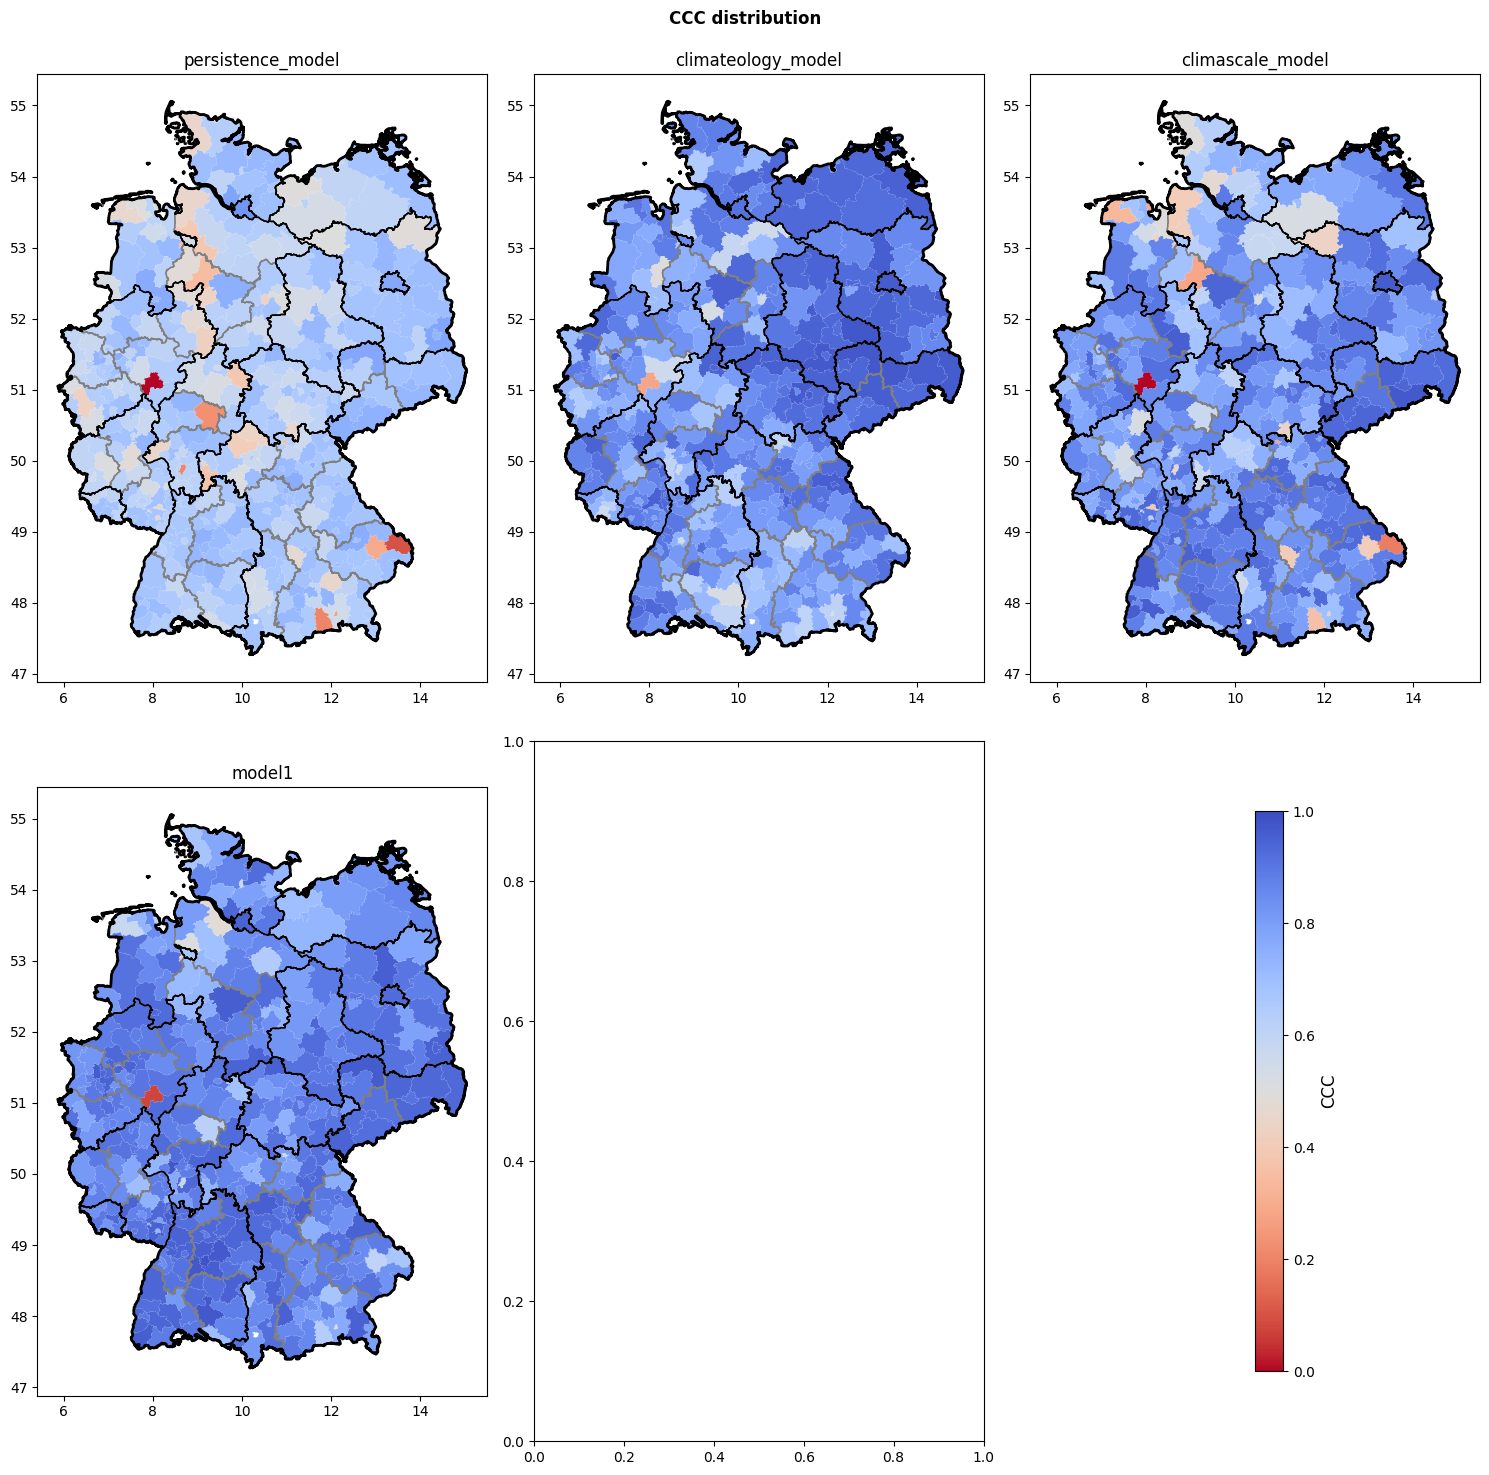

In [16]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

metric_df = ccc

fig, axes = plt.subplots(2, 3, figsize=(15, 15))
axes = axes.flatten()

ctx = epidata_orchestrator.data_context



map_df = gpd.GeoDataFrame(pd.merge(metric_df, gdf, on=['nuts_node']))

for idx, model in enumerate(list(metric_df.columns[1:])):

    data = map_df[['nuts_node', 'geometry', model]]
    data[model] = pd.to_numeric(data[model])
    data.plot(
        ax=axes[idx],
        column=model,
        cmap='coolwarm_r',
        vmin=0,
        vmax=1,
        legend=False       # no legend on any subplot
    )

    ctx.shapedata_nuts2.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'grey')
    ctx.shapedata_nuts1.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'black')
    ctx.shapedata_nuts0.plot(ax = axes[idx], facecolor = 'none', linewidth = 2, edgecolor = 'black')    
    axes[idx].set_title(model)

# --- colorbar in the last (empty) axis ---
last_ax = axes[-1]
last_ax.set_visible(False)          # hide the map frame/ticks

sm = ScalarMappable(cmap='coolwarm_r', norm=Normalize(vmin=0, vmax=1))
sm.set_array([])                    # required boilerplate

cbar = fig.colorbar(
    sm,
    ax=last_ax,                     # anchor to the empty axis
    fraction=0.5,                   # how much of the axis the cbar fills
    shrink=0.8,
    pad=0.05
)
cbar.set_label('CCC', fontsize=12)

fig.suptitle('CCC distribution', fontweight = 'bold')

plt.tight_layout()
plt.show()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a c

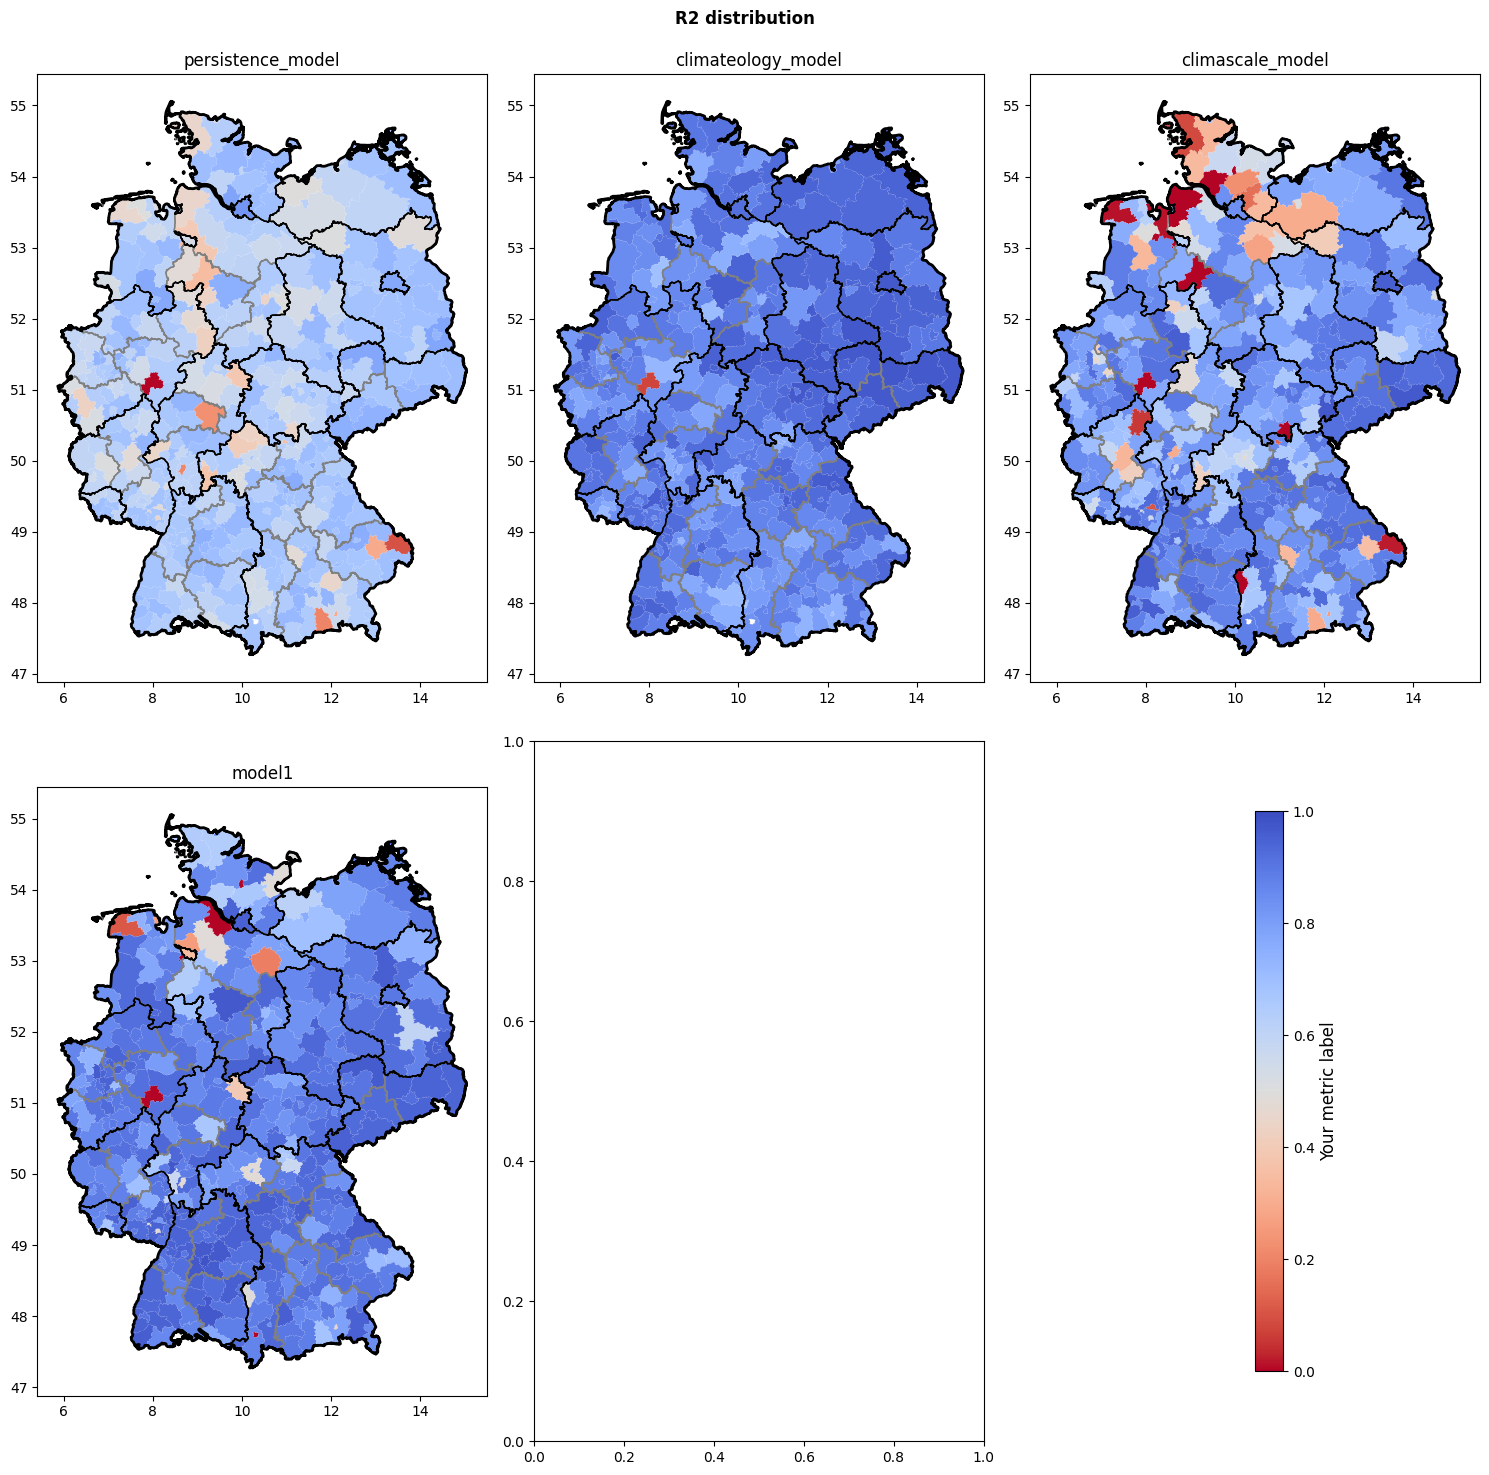

In [17]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

metric_df = r2

fig, axes = plt.subplots(2, 3, figsize=(15, 15))
axes = axes.flatten()

ctx = epidata_orchestrator.data_context



map_df = gpd.GeoDataFrame(pd.merge(metric_df, gdf, on=['nuts_node']))

for idx, model in enumerate(list(metric_df.columns[1:])):

    data = map_df[['nuts_node', 'geometry', model]]
    data[model] = pd.to_numeric(data[model])
    data.plot(
        ax=axes[idx],
        column=model,
        cmap='coolwarm_r',
        vmin=-1,
        vmax=1,
        legend=False       # no legend on any subplot
    )

    ctx.shapedata_nuts2.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'grey')
    ctx.shapedata_nuts1.plot(ax = axes[idx], facecolor = 'none', linewidth = 1, edgecolor = 'black')
    ctx.shapedata_nuts0.plot(ax = axes[idx], facecolor = 'none', linewidth = 2, edgecolor = 'black')    
    axes[idx].set_title(model)

# --- colorbar in the last (empty) axis ---
last_ax = axes[-1]
last_ax.set_visible(False)          # hide the map frame/ticks

sm = ScalarMappable(cmap='coolwarm_r', norm=Normalize(vmin=0, vmax=1))
sm.set_array([])                    # required boilerplate

cbar = fig.colorbar(
    sm,
    ax=last_ax,                     # anchor to the empty axis
    fraction=0.5,                   # how much of the axis the cbar fills
    shrink=0.8,
    pad=0.05
)
cbar.set_label('Your metric label', fontsize=12)

fig.suptitle('R2 distribution',fontweight = 'bold')
plt.tight_layout()
plt.show()